# Q3

Using the Mauna Lua CO2 dataset (monthly) perform forecasting using an MLP and compare the results with that of MA (Moving Average) and ARMA (Auto Regressive Moving Average)  models. Main setting: use previous “K” readings to predict next “T” reading. Example, if “K=3” and “T=1” then we use data from Jan, Feb, March and then predict the reading for April. Comment on why you observe such results. For MA or ARMA you can use any library or implement it from scratch. The choice of MLP is up to you. [2 marks]


Part 1: Using Moving Average, MA

In [1]:
# Loading the Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_model import ARIMA
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
import seaborn as sns
import warnings
from tqdm import tqdm

In [2]:
# Defining the Parameters
K = 5
T = 1

In [3]:
# Load the Mauna Loa CO2 dataset
data = pd.read_csv('co2_mm_mlo.csv')
data.head()

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.70,314.43,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.71,-1,-9.99,-0.99
3,1958,6,1958.4548,317.24,315.14,-1,-9.99,-0.99
4,1958,7,1958.5370,315.86,315.18,-1,-9.99,-0.99


In [4]:
# Calculate the moving average
ma = pd.DataFrame(columns=['Decimal Date', 'Original CO2'])
ma['Decimal Date'] = data['decimal date']
ma['Original CO2'] = data['average']

In [5]:
# Creating the Moving Average Columns for different K values
ma['ma_3'] = ma['Original CO2'].rolling(window=3, min_periods=1).mean()
ma['ma_5'] = ma['Original CO2'].rolling(window=5, min_periods=1).mean()
ma['ma_10'] = ma['Original CO2'].rolling(window=10, min_periods=1).mean()
ma['ma_20'] = ma['Original CO2'].rolling(window=20, min_periods=1).mean()
ma['ma_50'] = ma['Original CO2'].rolling(window=50, min_periods=1).mean()
ma['ma_100'] = ma['Original CO2'].rolling(window=100, min_periods=1).mean()
ma['ma_200'] = ma['Original CO2'].rolling(window=200, min_periods=1).mean()

ma.head()

,Decimal Date,Original CO2,ma_3,ma_5,ma_10,ma_20,ma_50,ma_100,ma_200
0,1958.2027,315.70,315.700000,315.700000,315.700000,315.700000,315.700000,315.700000,315.700000
1,1958.2877,317.45,316.575000,316.575000,316.575000,316.575000,316.575000,316.575000,316.575000
2,1958.3699,317.51,316.886667,316.886667,316.886667,316.886667,316.886667,316.886667,316.886667
3,1958.4548,317.24,317.400000,316.975000,316.975000,316.975000,316.975000,316.975000,316.975000
4,1958.5370,315.86,316.870000,316.752000,316.752000,316.752000,316.752000,316.752000,316.752000


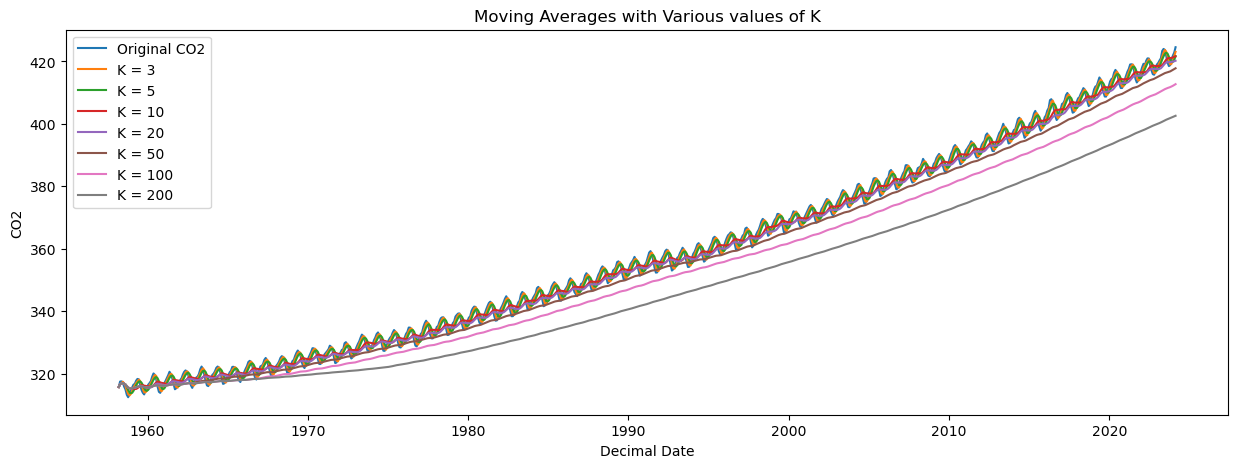

In [6]:
# Plot the Moving Averages
plt.figure(figsize=(15, 5))
plt.plot(ma['Decimal Date'], ma['Original CO2'], label='Original CO2')
plt.plot(ma['Decimal Date'], ma['ma_3'], label='K = 3')
plt.plot(ma['Decimal Date'], ma['ma_5'], label='K = 5')
plt.plot(ma['Decimal Date'], ma['ma_10'], label='K = 10')
plt.plot(ma['Decimal Date'], ma['ma_20'], label='K = 20')
plt.plot(ma['Decimal Date'], ma['ma_50'], label='K = 50')
plt.plot(ma['Decimal Date'], ma['ma_100'], label='K = 100')
plt.plot(ma['Decimal Date'], ma['ma_200'], label='K = 200')
plt.legend(loc='best')
plt.title(f'Moving Averages with Various values of K')
plt.xlabel('Decimal Date')
plt.ylabel('CO2')
plt.show()

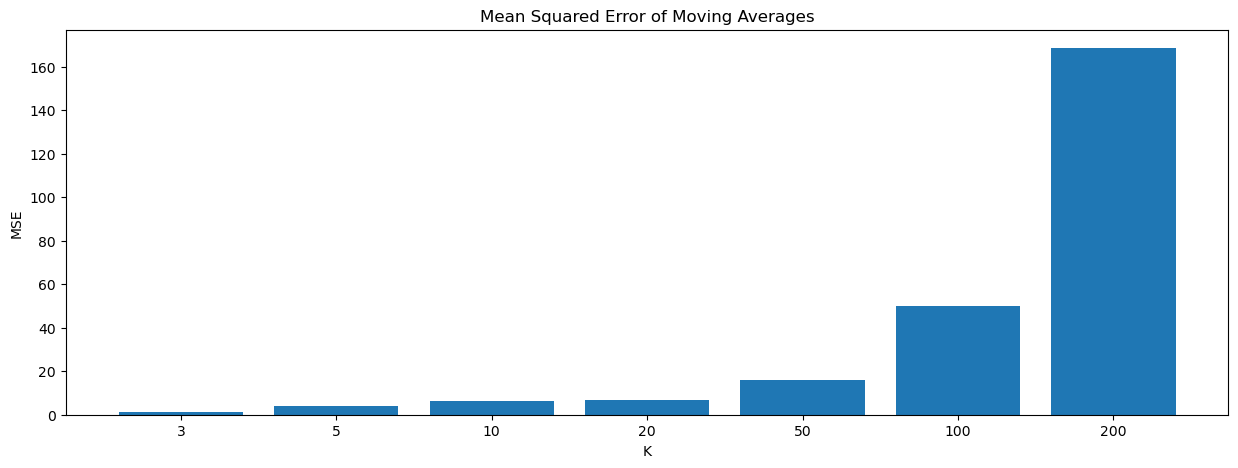

In [7]:
# Creating a Dictionary to store the Mean Squared Error of Moving Averages
ma_mse_dict = {}
ma_mse_dict[3] = mean_squared_error(ma['Original CO2'], ma['ma_3'])
ma_mse_dict[5] = mean_squared_error(ma['Original CO2'], ma['ma_5'])
ma_mse_dict[10] = mean_squared_error(ma['Original CO2'], ma['ma_10'])
ma_mse_dict[20] = mean_squared_error(ma['Original CO2'], ma['ma_20'])
ma_mse_dict[50] = mean_squared_error(ma['Original CO2'], ma['ma_50'])
ma_mse_dict[100] = mean_squared_error(ma['Original CO2'], ma['ma_100'])
ma_mse_dict[200] = mean_squared_error(ma['Original CO2'], ma['ma_200'])

# Plot the Mean Squared Error of Moving Averages
plt.figure(figsize=(15, 5))
plt.bar(list(map(str, list(ma_mse_dict.keys()))), ma_mse_dict.values())
plt.title(f'Mean Squared Error of Moving Averages')
plt.xlabel('K')
plt.ylabel('MSE')
plt.show()

MA Using statsmodels.tsa.arima

In [8]:
from statsmodels.tsa.arima.model import ARIMA # Importing the required library
length = ma['Decimal Date'].shape[0]
# ARMA, in simple terms, is the combination of the p order AR terms and the q order MA terms. If p = 0, it is an MA model. If d!= 0 , it is a ARIMA model.

In [9]:
ma1 = ma.copy()

In [25]:
# Creating the MA values for K = 3
ma1_3 = [] # Creating a list to store the values
K = 3
T = 1
for i in range(K+1):
    ma1_3.append(ma1['Original CO2'][i]) # Appending the first K values to the list

for step in tqdm(range(K+1, length)): # Looping through the data
    # print("The step is: ", step, "out of: ", length)
    warnings.filterwarnings("ignore")
    time_series_data = np.array(ma1['Original CO2'][:step]) # Obtaining the time series data
    # Fit an ARMA model (adjust order as needed)
    order = (0, 0, K) # Setting the order
    model = ARIMA(time_series_data, order=order) # Creating the ARIMA model
    model_fit = model.fit() # Fitting the model
    # Predict the next value
    next_value = model_fit.forecast(steps=1)
    # print(next_value)
    ma1_3.append(next_value[0]) # Appending the predicted value to the list

100%|██████████| 788/788 [00:11<00:00, 66.39it/s] 


In [26]:
# Creating the MA values for K = 5
ma1_5 = [] # Creating a list to store the  values
K = 5
T = 1
for i in range(K+1):
    ma1_5.append(ma1['Original CO2'][i]) # Appending the first K values to the list

for step in tqdm(range(K+1, length)): # Looping through the data
    # print("The step is: ", step, "out of: ", length)
    warnings.filterwarnings("ignore")
    time_series_data = np.array(ma1['Original CO2'][:step]) # Obtaining the time series data
    # Fit an ARMA model (adjust order as needed)
    order = (0, 0, K) # Setting the order
    model = ARIMA(time_series_data, order=order) # Creating the ARIMA model
    model_fit = model.fit() # Fitting the model
    # Predict the next value
    next_value = model_fit.forecast(steps=1)
    # print(next_value)
    ma1_5.append(next_value[0]) # Appending the predicted value to the list

100%|██████████| 786/786 [00:10<00:00, 76.39it/s] 


In [27]:
# Creating the MA values for K = 10
ma1_10 = [] # Creating a list to store the  values
K = 10
T = 1
for i in range(K+1):
    ma1_10.append(ma1['Original CO2'][i]) # Appending the first K values to the list

for step in tqdm(range(K+1, length)): # Looping through the data
    # print("The step is: ", step, "out of: ", length)
    warnings.filterwarnings("ignore")
    time_series_data = np.array(ma1['Original CO2'][:step]) # Obtaining the time series data
    # Fit an ARMA model (adjust order as needed)
    order = (0, 0, K) # Setting the order
    model = ARIMA(time_series_data, order=order) # Creating the ARIMA model
    model_fit = model.fit() # Fitting the model
    # Predict the next value
    next_value = model_fit.forecast(steps=1)
    # print(next_value)
    ma1_10.append(next_value[0]) # Appending the predicted value to the list

100%|██████████| 781/781 [00:31<00:00, 24.43it/s]


In [28]:
# Creating the MA values for K = 20
ma1_20 = [] # Creating a list to store the  values
K = 20
T = 1
for i in range(K+1):
    ma1_20.append(ma1['Original CO2'][i]) # Appending the first K values to the list

for step in tqdm(range(K+1, length)): # Looping through the data
    # print("The step is: ", step, "out of: ", length)
    warnings.filterwarnings("ignore")
    time_series_data = np.array(ma1['Original CO2'][:step]) # Obtaining the time series data
    # Fit an ARMA model (adjust order as needed)
    order = (0, 0, K) # Setting the order
    model = ARIMA(time_series_data, order=order) # Creating the ARIMA model
    model_fit = model.fit() # Fitting the model
    # Predict the next value
    next_value = model_fit.forecast(steps=1)
    # print(next_value)
    ma1_20.append(next_value[0]) # Appending the predicted value to the list

100%|██████████| 771/771 [02:59<00:00,  4.29it/s]


In [29]:
# Creating the MA values for K = 100
ma1_100 = [] # Creating a list to store the  values
K = 100
T = 1
for i in range(K+1):
    ma1_100.append(ma1['Original CO2'][i]) # Appending the first K values to the list

for step in tqdm(range(K+1, length)): # Looping through the data
    # print("The step is: ", step, "out of: ", length)
    warnings.filterwarnings("ignore")
    time_series_data = np.array(ma1['Original CO2'][:step]) # Obtaining the time series data
    # Fit an ARMA model (adjust order as needed)
    order = (0, 0, K) # Setting the order
    model = ARIMA(time_series_data, order=order) # Creating the ARIMA model
    model_fit = model.fit() # Fitting the model
    # Predict the next value
    next_value = model_fit.forecast(steps=1)
    # print(next_value)
    ma1_100.append(next_value[0]) # Appending the predicted value to the list

100%|██████████| 691/691 [32:34<00:00,  2.83s/it]


In [33]:
ma1['Decimal Date'] = data['decimal date']
ma1['Original CO2'] = data['average']
ma1['MA_3'] = ma1_3 # Storing the MA values in the dataframe
ma1['MA_5'] = ma1_5 # Storing the MA values in the dataframe
ma1['MA_10'] = ma1_10 # Storing the MA values in the dataframe
ma1['MA_20'] = ma1_20 # Storing the MA values in the dataframe
ma1['MA_100'] = ma1_100 # Storing the MA values in the dataframe


Text(0.5, 1.0, 'CO2 prediction for MA, K=3')

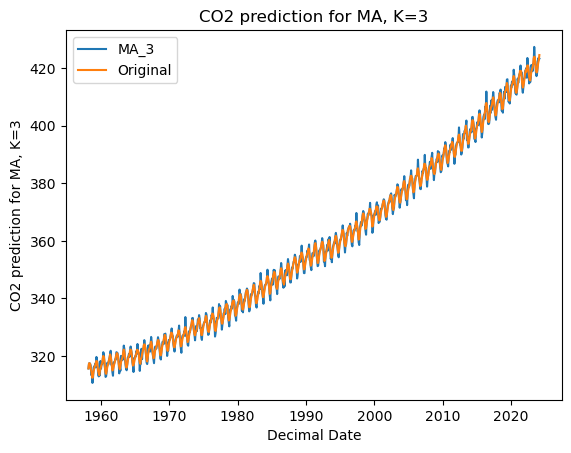

In [51]:
plt.plot(ma1['Decimal Date'],ma1_3, label='MA_3')
plt.plot(ma1['Decimal Date'],ma1['Original CO2'], label='Original')
plt.xlabel('Decimal Date')
plt.ylabel('CO2 prediction for MA, K=3')
plt.legend()
plt.title('CO2 prediction for MA, K=3')

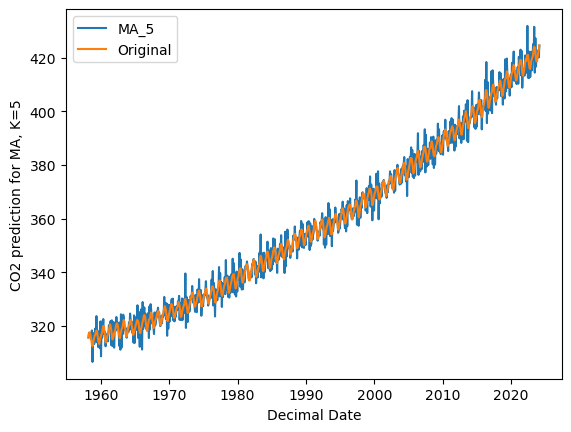

In [52]:
plt.plot(ma1['Decimal Date'],ma1_5, label='MA_5')
plt.plot(ma1['Decimal Date'],ma1['Original CO2'], label='Original')
plt.xlabel('Decimal Date')
plt.ylabel('CO2 prediction for MA, K=5')
plt.legend()

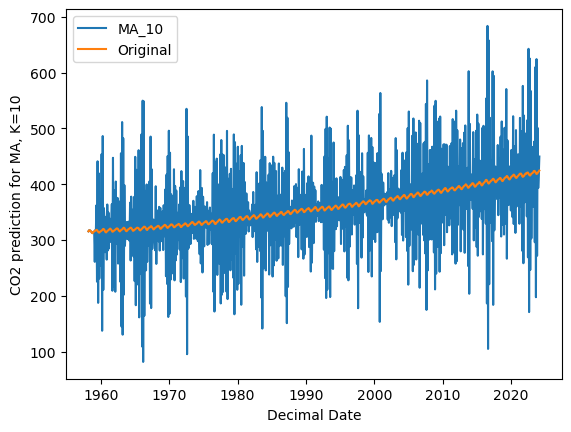

In [54]:
plt.plot(ma1['Decimal Date'],ma1_10, label='MA_10')
plt.plot(ma1['Decimal Date'],ma1['Original CO2'], label='Original')
plt.xlabel('Decimal Date')
plt.ylabel('CO2 prediction for MA, K=10')
plt.legend()

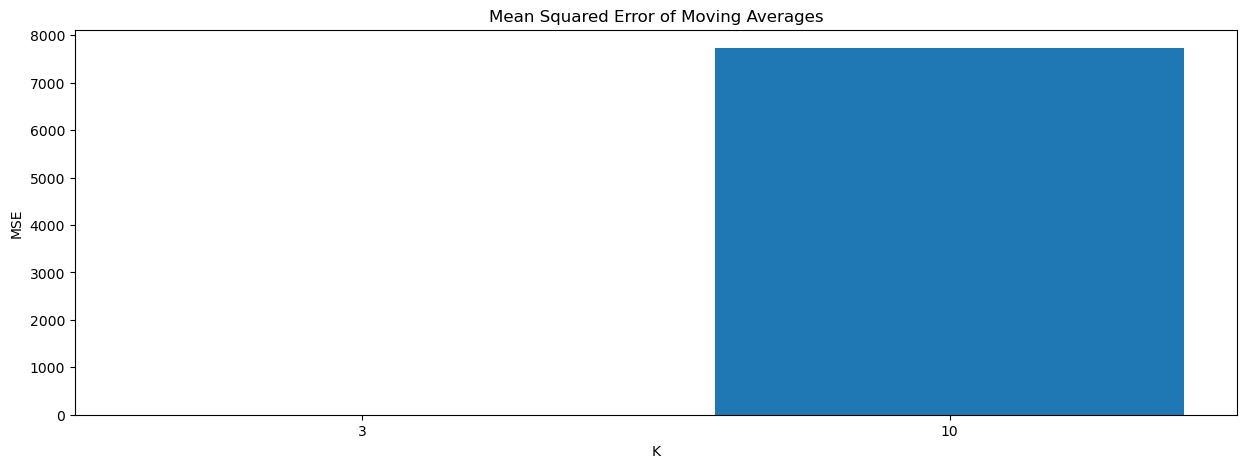

In [58]:
# Creating a Dictionary to store the Mean Squared Error of Moving Averages
ma1_mse_dict = {}
ma1_mse_dict[3] = mean_squared_error(ma1['Original CO2'], ma1['MA_3'])
ma1_mse_dict[10] = mean_squared_error(ma1['Original CO2'], ma1['MA_10'])

# Plot the Mean Squared Error of Moving Averages
plt.figure(figsize=(15, 5))
plt.bar(list(map(str, list(ma1_mse_dict.keys()))), ma1_mse_dict.values())
plt.title(f'Mean Squared Error of Moving Averages')
plt.xlabel('K')
plt.ylabel('MSE')
plt.show()

In [57]:
ma1_mse_dict

{3: 1.3477560605843453, 10: 7730.53930197595}

Part 2: ARMA: Auto Regressive Moving Average


In [11]:
from statsmodels.tsa.arima.model import ARIMA # Importing the required library

In [8]:
# Obtaining the required data and Creating a new Dataframe for ARMA
arma = pd.DataFrame(columns=['Decimal Date', 'Original CO2'])
arma['Decimal Date'] = data['decimal date']
arma['Original CO2'] = data['average']

In [9]:
length = arma['Decimal Date'].shape[0]
length

792

In [14]:
# Creating the ARMA values for K = 3
arma_3 = [] # Creating a list to store the ARMA values
K = 3
T = 1
for i in range(K+1):
    arma_3.append(arma['Original CO2'][i]) # Appending the first K values to the list

for step in tqdm(range(K+1, length)): # Looping through the data
    # print("The step is: ", step, "out of: ", length)
    warnings.filterwarnings("ignore")
    time_series_data = np.array(arma['Original CO2'][:step]) # Obtaining the time series data
    # Fit an ARMA model (adjust order as needed)
    order = (K, 0, K) # Setting the order
    model = ARIMA(time_series_data, order=order) # Creating the ARIMA model
    model_fit = model.fit() # Fitting the model
    # Predict the next value
    next_value = model_fit.forecast(steps=1)
    # print(next_value)
    arma_3.append(next_value[0]) # Appending the predicted value to the list

100%|██████████| 788/788 [19:00<00:00,  1.45s/it]


In [15]:
# Creating the ARMA values for K = 10
arma_10 = []
K = 10
T = 1
for i in range(K+1):
    arma_10.append(arma['Original CO2'][i])
for step in tqdm(range(K+1, length)):
    # print("The step is: ", step, "out of: ", length)
    warnings.filterwarnings("ignore")
    time_series_data = np.array(arma['Original CO2'][:step])
    # Fit an ARMA model (adjust order as needed)
    order = (K, 0, K)
    model = ARIMA(time_series_data, order=order)
    model_fit = model.fit()
    # Predict the next value
    next_value = model_fit.forecast(steps=1)
    # print(next_value)
    arma_10.append(next_value[0])

100%|██████████| 781/781 [1:25:56<00:00,  6.60s/it]


In [17]:
arma['Decimal Date'] = data['decimal date']
arma['Original CO2'] = data['average']
arma['ARMA_3'] = arma_3 # Storing the ARMA values in the dataframe
arma['ARMA_10'] = arma_10 # Storing the ARMA values in the dataframe
# arma['ARMA_100'] = arma_100
# arma['ARMA_500'] = arma_500


In [19]:
arma_mse_dict = {} # Creating a dictionary to store the Mean Squared Error of ARMA
arma_mse_dict[3] = mean_squared_error(arma['Original CO2'], arma['ARMA_3']) # Calculating the Mean Squared Error
arma_mse_dict[10] = mean_squared_error(arma['Original CO2'], arma['ARMA_10']) # Calculating the Mean Squared Error
# arma_mse_dict[100] = mean_squared_error(arma['Original CO2'], arma['MA_100'])
# arma_mse_dict[500] = mean_squared_error(arma['Original CO2'], arma['MA_500'])



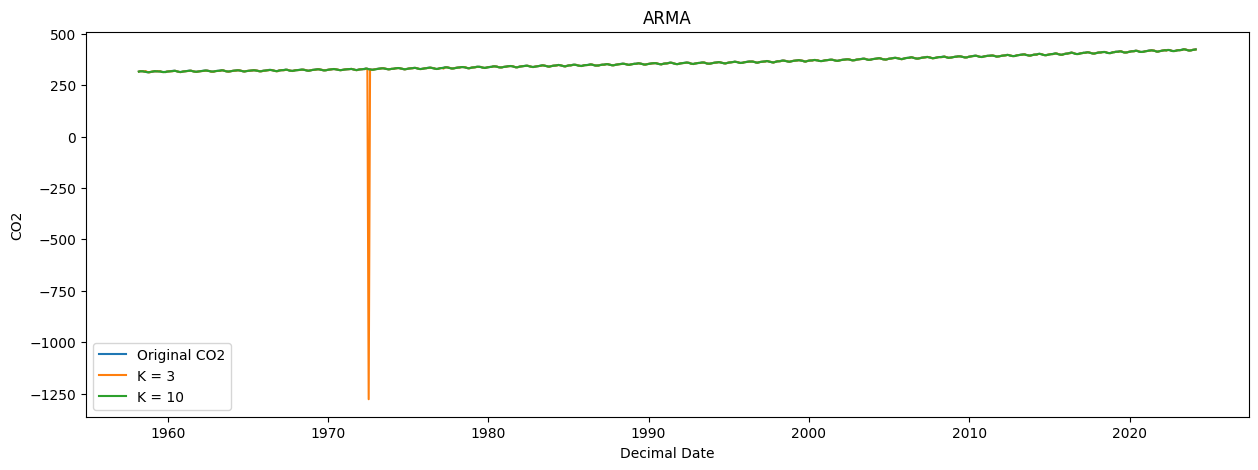

In [20]:
plt.figure(figsize=(15, 5)) # Plotting the ARMA values
plt.plot(arma['Decimal Date'], arma['Original CO2'], label='Original CO2')
plt.plot(arma['Decimal Date'], arma['ARMA_3'], label='K = 3')
plt.plot(arma['Decimal Date'] , arma['ARMA_10'], label='K = 10')
# plt.plot(arma['Decimal Date'], arma['ARMA_100'], label='K = 100')
# plt.plot(arma['Decimal Date'], arma['ARMA_500'], label='K = 500')
plt.legend(loc='best')
plt.title(f'ARMA')
plt.xlabel('Decimal Date')
plt.ylabel('CO2')
plt.show()

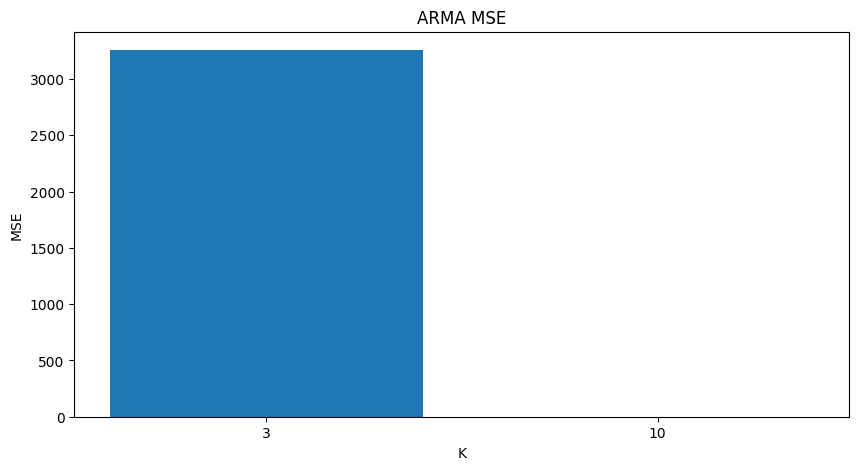

In [21]:
plt.figure(figsize=(10, 5)) # Plotting the Mean Squared Error of ARMA
plt.bar(list(map(str, arma_mse_dict.keys())), arma_mse_dict.values())
plt.title('ARMA MSE')
plt.xlabel('K')
plt.ylabel('MSE')
plt.show()

In [23]:
arma_mse_dict # Printing the Mean Squared Error of ARMA

{3: 3256.2105777134902, 10: 0.33579227206404216}

Part 3: MLP

In [6]:
# Importing the required library
from sklearn.neural_network import MLPRegressor


In [21]:
mlp = pd.DataFrame(columns=['Decimal Date', 'Original CO2']) # Creating a new Dataframe for MLP
mlp['Decimal Date'] = data['decimal date'] # Storing the Decimal Date
mlp['Original CO2'] = data['average'] # Storing the Original CO2

## Creating the MLP values for K = 3
mlp_3 = [] # Creating a list to store the MLP values
K = 3
T = 3
for i in range(K+1): # Appending the first K values to the list
    mlp_3.append(list(mlp['Original CO2'])[i]) 

for step in tqdm(range(K+1, length)): # Looping through the data
    warnings.filterwarnings("ignore")
    # print("The step is: ", step, "out of: ", length)
    time_series_given_y = np.array(mlp['Original CO2'][step-K:step]) # Obtaining the time series data
    time_series_given_x = np.array(mlp['Decimal Date'][step-K:step]) # Obtaining the time series data
    time_series_pred_y = np.array(mlp['Original CO2'][step:step+T]) # Obtaining the time series data
    time_series_pred_x = np.array(mlp['Decimal Date'][step:step+T]) # Obtaining the time series data

    model = MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=1000) # Creating the MLP model
    model_fit = model.fit(time_series_given_x.reshape(-1, 1), time_series_given_y) # Fitting the model
    # Predict the next value

    next_value = model_fit.predict(time_series_pred_x.reshape(-1, 1)) # Predicting the next value
    # print(next_value)
    if len(mlp_3)<step: # Appending the predicted value to the list
        mlp_3[step].append(next_value[0]) 
    else:
        mlp_3.append(list(next_value)[0])

mlp_3 = [np.mean(x) for x in mlp_3] # Taking the mean of the predicted values



100%|██████████| 788/788 [00:19<00:00, 40.12it/s]


In [22]:
mlp = pd.DataFrame(columns=['Decimal Date', 'Original CO2'])
mlp['Decimal Date'] = data['decimal date']
mlp['Original CO2'] = data['average']
# K = 5, T = 3
mlp_5 = []
K = 5
T = 3
for i in range(K+1):
    mlp_5.append(list(mlp['Original CO2'])[i])

for step in tqdm(range(K+1, length)):
    warnings.filterwarnings("ignore")
    # print("The step is: ", step, "out of: ", length)
    time_series_given_y = np.array(mlp['Original CO2'][step-K:step])
    time_series_given_x = np.array(mlp['Decimal Date'][step-K:step])
    time_series_pred_y = np.array(mlp['Original CO2'][step:step+T])
    time_series_pred_x = np.array(mlp['Decimal Date'][step:step+T])

    model = MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=1000)
    model_fit = model.fit(time_series_given_x.reshape(-1, 1), time_series_given_y)
    # Predict the next value

    next_value = model_fit.predict(time_series_pred_x.reshape(-1, 1))
    # print(next_value)
    if len(mlp_5)<step:
        mlp_5[step].append(next_value[0])
    else:
        mlp_5.append(list(next_value)[0])

mlp_5 = [np.mean(x) for x in mlp_5]



100%|██████████| 786/786 [00:19<00:00, 40.27it/s]


In [23]:
mlp = pd.DataFrame(columns=['Decimal Date', 'Original CO2'])
mlp['Decimal Date'] = data['decimal date']
mlp['Original CO2'] = data['average']
# K = 10, T = 5
mlp_10 = []
K = 10
T = 5
for i in range(K+1):
    mlp_10.append(list(mlp['Original CO2'])[i])

for step in tqdm(range(K+1, length)):
    warnings.filterwarnings("ignore")
    # print("The step is: ", step, "out of: ", length)
    time_series_given_y = np.array(mlp['Original CO2'][step-K:step])
    time_series_given_x = np.array(mlp['Decimal Date'][step-K:step])
    time_series_pred_y = np.array(mlp['Original CO2'][step:step+T])
    time_series_pred_x = np.array(mlp['Decimal Date'][step:step+T])

    model = MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=1000)
    model_fit = model.fit(time_series_given_x.reshape(-1, 1), time_series_given_y)
    # Predict the next value

    next_value = model_fit.predict(time_series_pred_x.reshape(-1, 1))
    # print(next_value)
    if len(mlp_10)<step:
        mlp_10[step].append(next_value[0])
    else:
        mlp_10.append(list(next_value)[0])

mlp_10 = [np.mean(x) for x in mlp_10]



100%|██████████| 781/781 [00:19<00:00, 40.79it/s]


In [24]:
mlp = pd.DataFrame(columns=['Decimal Date', 'Original CO2'])
mlp['Decimal Date'] = data['decimal date']
mlp['Original CO2'] = data['average']
# K = 20, T = 5
mlp_20 = []
K = 20
T = 5
for i in range(K+1):
    mlp_20.append(list(mlp['Original CO2'])[i])

for step in tqdm(range(K+1, length)):
    warnings.filterwarnings("ignore")
    # print("The step is: ", step, "out of: ", length)
    time_series_given_y = np.array(mlp['Original CO2'][step-K:step])
    time_series_given_x = np.array(mlp['Decimal Date'][step-K:step])
    time_series_pred_y = np.array(mlp['Original CO2'][step:step+T])
    time_series_pred_x = np.array(mlp['Decimal Date'][step:step+T])

    model = MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=1000)
    model_fit = model.fit(time_series_given_x.reshape(-1, 1), time_series_given_y)
    # Predict the next value

    next_value = model_fit.predict(time_series_pred_x.reshape(-1, 1))
    # print(next_value)
    if len(mlp_20)<step:
        mlp_20[step].append(next_value[0])
    else:
        mlp_20.append(list(next_value)[0])

mlp_20 = [np.mean(x) for x in mlp_20]



100%|██████████| 771/771 [00:19<00:00, 39.52it/s]


In [25]:
mlp = pd.DataFrame(columns=['Decimal Date', 'Original CO2'])
mlp['Decimal Date'] = data['decimal date']
mlp['Original CO2'] = data['average']
# K = 50, T = 25
mlp_50 = []
K = 50
T = 25
for i in range(K+1):
    mlp_50.append(list(mlp['Original CO2'])[i])

for step in tqdm(range(K+1, length)):
    warnings.filterwarnings("ignore")
    # print("The step is: ", step, "out of: ", length)
    time_series_given_y = np.array(mlp['Original CO2'][step-K:step])
    time_series_given_x = np.array(mlp['Decimal Date'][step-K:step])
    time_series_pred_y = np.array(mlp['Original CO2'][step:step+T])
    time_series_pred_x = np.array(mlp['Decimal Date'][step:step+T])

    model = MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=1000)
    model_fit = model.fit(time_series_given_x.reshape(-1, 1), time_series_given_y)
    # Predict the next value

    next_value = model_fit.predict(time_series_pred_x.reshape(-1, 1))
    # print(next_value)
    if len(mlp_50)<step:
        mlp_50[step].append(next_value[0])
    else:
        mlp_50.append(list(next_value)[0])

mlp_50 = [np.mean(x) for x in mlp_50]


100%|██████████| 741/741 [00:20<00:00, 36.54it/s]


In [26]:
mlp = pd.DataFrame(columns=['Decimal Date', 'Original CO2'])
mlp['Decimal Date'] = data['decimal date']
mlp['Original CO2'] = data['average']

mlp_100 = []
K = 100
T = 50
for i in range(K+1):
    mlp_100.append(list(mlp['Original CO2'])[i])

for step in tqdm(range(K+1, length)):
    warnings.filterwarnings("ignore")
    # print("The step is: ", step, "out of: ", length)
    time_series_given_y = np.array(mlp['Original CO2'][step-K:step])
    time_series_given_x = np.array(mlp['Decimal Date'][step-K:step])
    time_series_pred_y = np.array(mlp['Original CO2'][step:step+T])
    time_series_pred_x = np.array(mlp['Decimal Date'][step:step+T])

    model = MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=1000)
    model_fit = model.fit(time_series_given_x.reshape(-1, 1), time_series_given_y)
    # Predict the next value

    next_value = model_fit.predict(time_series_pred_x.reshape(-1, 1))
    # print(next_value)
    if len(mlp_100)<step:
        mlp_100[step].append(next_value[0])
    else:
        mlp_100.append(list(next_value)[0])

mlp_100 = [np.mean(x) for x in mlp_100]



100%|██████████| 691/691 [00:22<00:00, 31.19it/s]


In [27]:
mlp = pd.DataFrame(columns=['Decimal Date', 'Original CO2'])
mlp['Decimal Date'] = data['decimal date']
mlp['Original CO2'] = data['average']

mlp_200 = []
K = 200
T = 100
for i in range(K+1):
    mlp_200.append(list(mlp['Original CO2'])[i])

for step in tqdm(range(K+1, length)):
    warnings.filterwarnings("ignore")
    # print("The step is: ", step, "out of: ", length)
    time_series_given_y = np.array(mlp['Original CO2'][step-K:step])
    time_series_given_x = np.array(mlp['Decimal Date'][step-K:step])
    time_series_pred_y = np.array(mlp['Original CO2'][step:step+T])
    time_series_pred_x = np.array(mlp['Decimal Date'][step:step+T])

    model = MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=1000)
    model_fit = model.fit(time_series_given_x.reshape(-1, 1), time_series_given_y)
    # Predict the next value

    next_value = model_fit.predict(time_series_pred_x.reshape(-1, 1))
    # print(next_value)
    if len(mlp_200)<step:
        mlp_200[step].append(next_value[0])
    else:
        mlp_200.append(list(next_value)[0])

mlp_200 = [np.mean(x) for x in mlp_200]



  0%|          | 0/591 [00:00<?, ?it/s]

100%|██████████| 591/591 [00:21<00:00, 26.87it/s]


In [28]:
mlp = pd.DataFrame(columns=['Decimal Date', 'Original CO2']) # Creating a new Dataframe for MLP
mlp['Decimal Date'] = data['decimal date']
mlp['Original CO2'] = data['average']
# Adding the MLP prediction values to the columns of DF
mlp['MLP_3'] = mlp_3
mlp['MLP_5'] = mlp_5
mlp['MLP_10'] = mlp_10
mlp['MLP_20'] = mlp_20
mlp['MLP_50'] = mlp_50
mlp['MLP_100'] = mlp_100
mlp['MLP_200'] = mlp_200


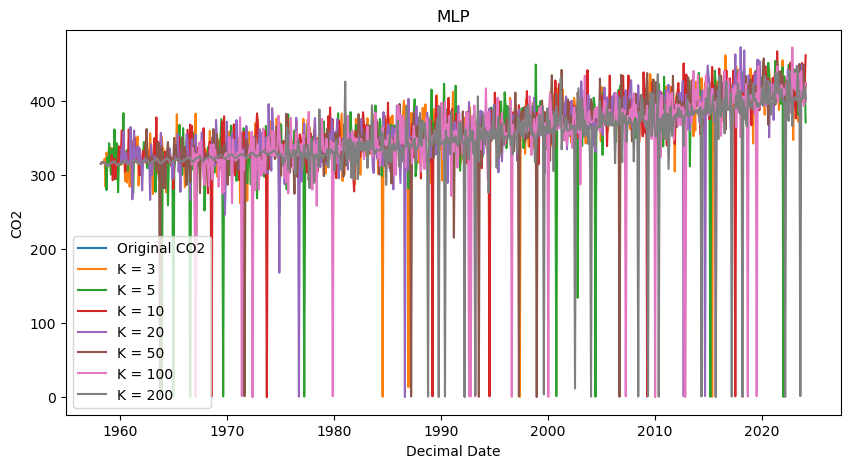

In [29]:
plt.figure(figsize=(10, 5)) # Plotting the MLP values
plt.plot(mlp['Decimal Date'], mlp['Original CO2'], label='Original CO2')
plt.plot(mlp['Decimal Date'], mlp['MLP_3'], label='K = 3')
plt.plot(mlp['Decimal Date'], mlp['MLP_5'], label='K = 5')
plt.plot(mlp['Decimal Date'], mlp['MLP_10'], label='K = 10')
plt.plot(mlp['Decimal Date'], mlp['MLP_20'], label='K = 20')
plt.plot(mlp['Decimal Date'], mlp['MLP_50'], label='K = 50')
plt.plot(mlp['Decimal Date'], mlp['MLP_100'], label='K = 100')
plt.plot(mlp['Decimal Date'], mlp['MLP_200'], label='K = 200')
plt.title('MLP')
plt.xlabel('Decimal Date')
plt.ylabel('CO2')
plt.legend(loc='best')
plt.show()

In [30]:
mlp_mse_dict = {} # Creating a dictionary to store the Mean Squared Error of MLP
mlp_mse_dict[3] = mean_squared_error(mlp['Original CO2'][3:], mlp['MLP_3'][3:])
mlp_mse_dict[5] = mean_squared_error(mlp['Original CO2'][5:], mlp['MLP_5'][5:])
mlp_mse_dict[10] = mean_squared_error(mlp['Original CO2'][10:], mlp['MLP_10'][10:])
mlp_mse_dict[20] = mean_squared_error(mlp['Original CO2'][20:], mlp['MLP_20'][20:])
mlp_mse_dict[50] = mean_squared_error(mlp['Original CO2'][50:], mlp['MLP_50'][50:])
mlp_mse_dict[100] = mean_squared_error(mlp['Original CO2'][100:], mlp['MLP_100'][100:])
mlp_mse_dict[200]= mean_squared_error(mlp['Original CO2'][200:], mlp['MLP_200'][200:])

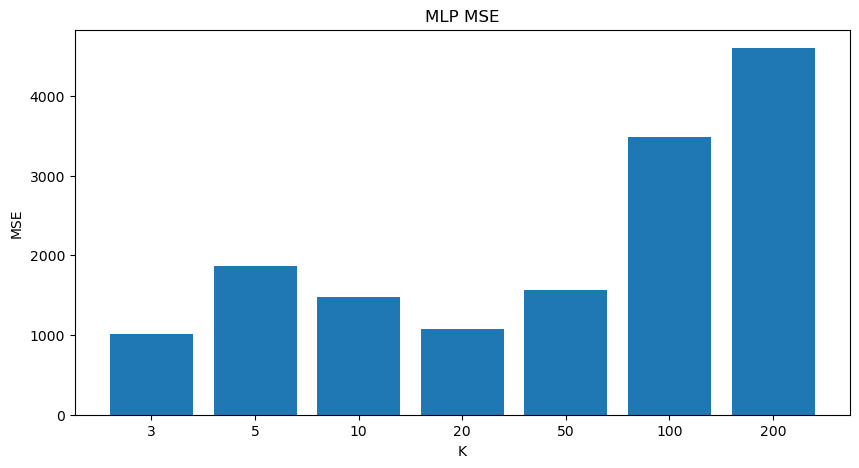

In [31]:
plt.figure(figsize=(10, 5)) # Plotting the Mean Squared Error of MLP
plt.bar(list(map(str, mlp_mse_dict.keys())), mlp_mse_dict.values())
plt.title('MLP MSE')
plt.xlabel('K')
plt.ylabel('MSE')
plt.show()

In [32]:
mlp = pd.DataFrame(columns=['Decimal Date', 'Original CO2']) # Creating a new Dataframe for MLP
mlp['Decimal Date'] = data['decimal date'] # Storing the Decimal Date
mlp['Original CO2'] = data['average'] # Storing the Original CO2

## Creating the MLP values for K = 3
mlp_3 = [] # Creating a list to store the MLP values
K = 3
T = 1
for i in range(K+1): # Appending the first K values to the list
    mlp_3.append(list(mlp['Original CO2'])[i]) 

for step in tqdm(range(K+1, length)): # Looping through the data
    warnings.filterwarnings("ignore")
    # print("The step is: ", step, "out of: ", length)
    time_series_given_y = np.array(mlp['Original CO2'][step-K:step]) # Obtaining the time series data
    time_series_given_x = np.array(mlp['Decimal Date'][step-K:step]) # Obtaining the time series data
    time_series_pred_y = np.array(mlp['Original CO2'][step:step+T]) # Obtaining the time series data
    time_series_pred_x = np.array(mlp['Decimal Date'][step:step+T]) # Obtaining the time series data

    model = MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=1000) # Creating the MLP model
    model_fit = model.fit(time_series_given_x.reshape(-1, 1), time_series_given_y) # Fitting the model
    # Predict the next value

    next_value = model_fit.predict(time_series_pred_x.reshape(-1, 1)) # Predicting the next value
    # print(next_value)
    if len(mlp_3)<step: # Appending the predicted value to the list
        mlp_3[step].append(next_value[0]) 
    else:
        mlp_3.append(list(next_value)[0])

mlp_3 = [np.mean(x) for x in mlp_3] # Taking the mean of the predicted values



100%|██████████| 788/788 [00:18<00:00, 42.41it/s]


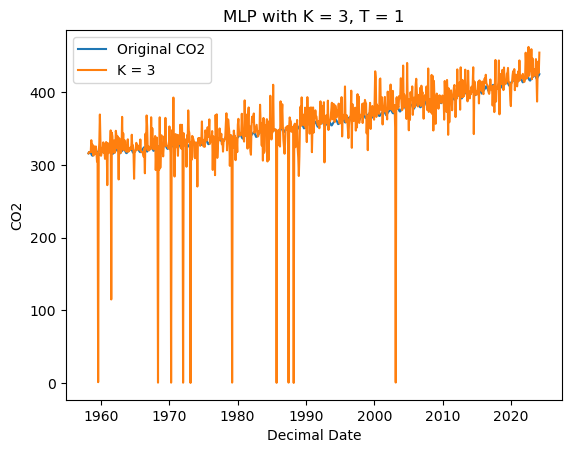

In [33]:
plt.plot(mlp['Decimal Date'], mlp['Original CO2'], label='Original CO2')
plt.plot(mlp['Decimal Date'], mlp_3, label='K = 3')
plt.legend(loc='best')
plt.title('MLP with K = 3, T = 1')
plt.xlabel('Decimal Date')
plt.ylabel('CO2')
plt.show()


In [34]:
print("The MSE value is: ", mean_squared_error(mlp['Original CO2'][3:], mlp_3[3:]))

The MSE value is:  1817.531208905525


100%|██████████| 781/781 [00:20<00:00, 38.55it/s]


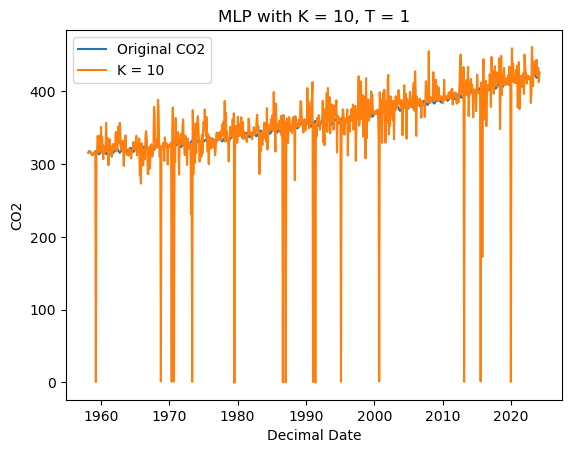

The MSE value is:  2810.075243793259


In [40]:
mlp = pd.DataFrame(columns=['Decimal Date', 'Original CO2']) # Creating a new Dataframe for MLP
mlp['Decimal Date'] = data['decimal date'] # Storing the Decimal Date
mlp['Original CO2'] = data['average'] # Storing the Original CO2

## Creating the MLP values for K = 10
mlp_3 = [] # Creating a list to store the MLP values
K = 10
T = 1
for i in range(K+1): # Appending the first K values to the list
    mlp_3.append(list(mlp['Original CO2'])[i]) 

for step in tqdm(range(K+1, length)): # Looping through the data
    warnings.filterwarnings("ignore")
    # print("The step is: ", step, "out of: ", length)
    time_series_given_y = np.array(mlp['Original CO2'][step-K:step]) # Obtaining the time series data
    time_series_given_x = np.array(mlp['Decimal Date'][step-K:step]) # Obtaining the time series data
    time_series_pred_y = np.array(mlp['Original CO2'][step:step+T]) # Obtaining the time series data
    time_series_pred_x = np.array(mlp['Decimal Date'][step:step+T]) # Obtaining the time series data

    model = MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=1000) # Creating the MLP model
    model_fit = model.fit(time_series_given_x.reshape(-1, 1), time_series_given_y) # Fitting the model
    # Predict the next value

    next_value = model_fit.predict(time_series_pred_x.reshape(-1, 1)) # Predicting the next value
    # print(next_value)
    if len(mlp_3)<step: # Appending the predicted value to the list
        mlp_3[step].append(next_value[0]) 
    else:
        mlp_3.append(list(next_value)[0])

mlp_3 = [np.mean(x) for x in mlp_3] # Taking the mean of the predicted values
plt.plot(mlp['Decimal Date'], mlp['Original CO2'], label='Original CO2')
plt.plot(mlp['Decimal Date'], mlp_3, label='K = 10')
plt.legend(loc='best')
plt.title('MLP with K = 10, T = 1')
plt.xlabel('Decimal Date')
plt.ylabel('CO2')
plt.show()
print("The MSE value is: ", mean_squared_error(mlp['Original CO2'][10:], mlp_3[10:]))

100%|██████████| 741/741 [00:20<00:00, 36.12it/s]


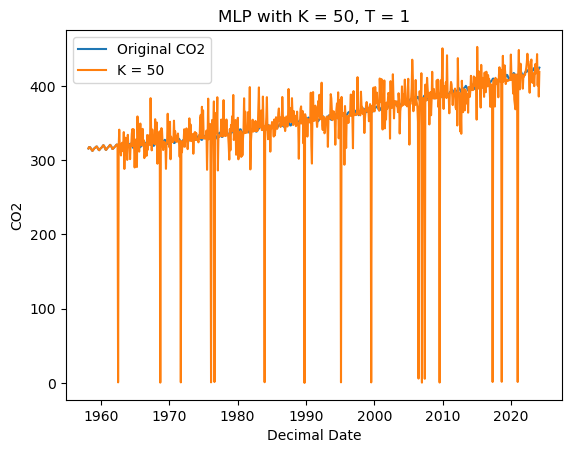

The MSE value is:  3168.1229746308204


In [41]:
mlp = pd.DataFrame(columns=['Decimal Date', 'Original CO2']) # Creating a new Dataframe for MLP
mlp['Decimal Date'] = data['decimal date'] # Storing the Decimal Date
mlp['Original CO2'] = data['average'] # Storing the Original CO2

## Creating the MLP values for K = 10
mlp_3 = [] # Creating a list to store the MLP values
K = 50
T = 1
for i in range(K+1): # Appending the first K values to the list
    mlp_3.append(list(mlp['Original CO2'])[i]) 

for step in tqdm(range(K+1, length)): # Looping through the data
    warnings.filterwarnings("ignore")
    # print("The step is: ", step, "out of: ", length)
    time_series_given_y = np.array(mlp['Original CO2'][step-K:step]) # Obtaining the time series data
    time_series_given_x = np.array(mlp['Decimal Date'][step-K:step]) # Obtaining the time series data
    time_series_pred_y = np.array(mlp['Original CO2'][step:step+T]) # Obtaining the time series data
    time_series_pred_x = np.array(mlp['Decimal Date'][step:step+T]) # Obtaining the time series data

    model = MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=1000) # Creating the MLP model
    model_fit = model.fit(time_series_given_x.reshape(-1, 1), time_series_given_y) # Fitting the model
    # Predict the next value

    next_value = model_fit.predict(time_series_pred_x.reshape(-1, 1)) # Predicting the next value
    # print(next_value)
    if len(mlp_3)<step: # Appending the predicted value to the list
        mlp_3[step].append(next_value[0]) 
    else:
        mlp_3.append(list(next_value)[0])

mlp_3 = [np.mean(x) for x in mlp_3] # Taking the mean of the predicted values
plt.plot(mlp['Decimal Date'], mlp['Original CO2'], label='Original CO2')
plt.plot(mlp['Decimal Date'], mlp_3, label='K = 50')
plt.legend(loc='best')
plt.title('MLP with K = 50, T = 1')
plt.xlabel('Decimal Date')
plt.ylabel('CO2')
plt.show()
print("The MSE value is: ", mean_squared_error(mlp['Original CO2'][50:], mlp_3[50:]))

100%|██████████| 691/691 [00:21<00:00, 31.75it/s]


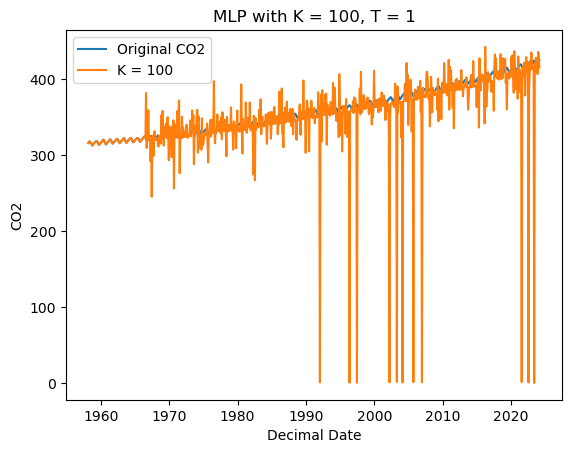

The MSE value is:  2657.3161181765245


In [42]:
mlp = pd.DataFrame(columns=['Decimal Date', 'Original CO2']) # Creating a new Dataframe for MLP
mlp['Decimal Date'] = data['decimal date'] # Storing the Decimal Date
mlp['Original CO2'] = data['average'] # Storing the Original CO2

## Creating the MLP values for K = 100
mlp_3 = [] # Creating a list to store the MLP values
K = 100
T = 1
for i in range(K+1): # Appending the first K values to the list
    mlp_3.append(list(mlp['Original CO2'])[i]) 

for step in tqdm(range(K+1, length)): # Looping through the data
    warnings.filterwarnings("ignore")
    # print("The step is: ", step, "out of: ", length)
    time_series_given_y = np.array(mlp['Original CO2'][step-K:step]) # Obtaining the time series data
    time_series_given_x = np.array(mlp['Decimal Date'][step-K:step]) # Obtaining the time series data
    time_series_pred_y = np.array(mlp['Original CO2'][step:step+T]) # Obtaining the time series data
    time_series_pred_x = np.array(mlp['Decimal Date'][step:step+T]) # Obtaining the time series data

    model = MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=1000) # Creating the MLP model
    model_fit = model.fit(time_series_given_x.reshape(-1, 1), time_series_given_y) # Fitting the model
    # Predict the next value

    next_value = model_fit.predict(time_series_pred_x.reshape(-1, 1)) # Predicting the next value
    # print(next_value)
    if len(mlp_3)<step: # Appending the predicted value to the list
        mlp_3[step].append(next_value[0]) 
    else:
        mlp_3.append(list(next_value)[0])

mlp_3 = [np.mean(x) for x in mlp_3] # Taking the mean of the predicted values
plt.plot(mlp['Decimal Date'], mlp['Original CO2'], label='Original CO2')
plt.plot(mlp['Decimal Date'], mlp_3, label='K = 100')
plt.legend(loc='best')
plt.title('MLP with K = 100, T = 1')
plt.xlabel('Decimal Date')
plt.ylabel('CO2')
plt.show()
print("The MSE value is: ", mean_squared_error(mlp['Original CO2'][100:], mlp_3[100:]))

## Observations

* Starting with the analysis of runtime for this particular task, the trivial MA was very fast compared to MLP regressor, MA and the ARMA was the slowest methodology to predict.

* In the predictions of the trivial MA, we can observe slight lag for lower values of K, while there was a significant lag for the larger values of K.
* For higher K values, we can also observe that the prediction is farther away from the actual values, however, it tries to capture the trend.
* The lower values of K capture it quite well.
* This particular trend is also exhibited in the plot of MSE of the trivial MA prediction values, that for larger values of K, the MSE value tends to increase.
* This is because the trivial MA model works with the mean of the previous K values, as the corr between the adjacent observations is generally more, so we are getting a more accurate answer.
#### Actual MA, ARMA and MLP
Comparison for T = 1
<table>
  <tr>
    <th>Model</th>
    <th>K</th>
    <th>MSE</th>
  </tr>

  <tr>
    <td>3</td>
    <td>MA</td>
    <td>1.3477560605843453</td>
  </tr>
  <tr>
    <td>10</td>
    <td>MA</td>
    <td>7730.53930197595</td>
  </tr>
  <tr>
    <td>3</td>
    <td>ARMA</td>
    <td>3256.2105777134902</td>
  </tr>
  <tr>
    <td>10</td>
    <td>ARMA</td>
    <td>0.33579227206404216</td>
  </tr>

  <tr>
    <td>3</td>
    <td>MLP</td>
    <td>1817.531208905525</td>
  </tr>
  <tr>
    <td>10</td>
    <td>MLP</td>
    <td>2810.075243793259</td>
  </tr>
</table>

* Considering the actual MA model, which gives the output based on the previous K values, we can see that the MA model output for the low K values was more accurate than the MA model output for larger K values. 

* This is certainly because of the more correlation between the adjacent nearby points compared to the far away points.
* The farther away points vary the coefficients in such a way that the predictions are away from the current values. Morover, this is also not a stationary curve.
* Coming to the discussion of ARMA, the first observation is that it takes a lot of time to run.
* The ARMA model prediction for K = 3 and K = 10 has been plotted. We can observe that the ARMA  model also tends to follow the trends quite well, infact better that MA in most of the cases.
* However, we can also see that the ARMA for K = 3 shows a sudden spike downwards which may be a result of some computational result.
* We can also observe this from the plot of MSE. We can see that the irregularity based spike of the K = 3 has contributed to major part ARMA MSE.
* However, for the value of K = 10, the value of ARMA MSE is very less; much less than MA MSE for K = 10.
* However, the process is computationally very expensive practically.
* This is because the model is much more powerful than the MA due to the consideration of partial corelations as well.
* Coming to the observations from MLP, we can see that the results for MLP prediction are relatively much worse than those of MA and ARMA.
* We can roughly see that the trend is clear that the error in the prediction will be expected to be less if K is more as we will see a larger amount of data.
* However this trend is not always right.
* If we see the trend for the same value of T = 1, we can see the observations as given:

<table>
  <tr>
    <th>K</th>
    <th>MSE</th>
  </tr>
  <tr>
    <td>3</td>
    <td>1817.531208905525</td>
  </tr>
  <tr>
    <td>10</td>
    <td>2810.075243793259</td>
  </tr>
  <tr>
    <td>50</td>
    <td>3168.1229746308204</td>
  </tr>
  <tr>
    <td>100</td>
    <td>2657.3161181765245</td>
  </tr>
</table>

* The reason for this may be that the model may be trained well only for predicting the values for date in the decimal date range used for training it. If the value fall out side the range, the parameter values may give vague results as they may not be well tuned for the prediction of values outside the range. the second reason may be that we may not have reached the global minimum. Though we have run 1000 iterations, we may be far from the minimum but we can get there at the cost of more computational resources.